<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/analisis_datos/blob/main/01_Clasificación_Bayesiana/Caso_4.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [9]:
#################################################
# Autor: Wilfrido Gómez Flores (Cinvestav)      #
# E-mail: wgomez@cinvestav.mx                   #
# Curso:   Análisis de datos                    #
# Tópico:  Clasificador naive Bayes             #
#################################################

Carga bibliotecas necesarias

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Carga el conjunto de datos Iris con 3 clases, 150 muestras y 4 variables

In [11]:
iris = load_iris()
df = pd.DataFrame(data=iris.data)
X = df.to_numpy() # Características
df = pd.DataFrame(data=iris.target)
Y = df.to_numpy() # Etiquetas de clase: 1,2 3
d = X.shape[1] # Número de variables
c = np.unique(Y).size # Número de clases

Divide el conjunto de datos en 80\% para entrenamiento y 20\% para prueba

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

Normaliza el conjunto de datos con z-score:  $z = \frac{x-\mu}{\sigma}$

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Normaliza el conjunto de entrenamiento
X_test = scaler.transform(X_test) # Normaliza el conjunto de prueba usando los estadísticos del conjunto de entrenamiento

Funciones de entrenamiento y predicción con clasificador naive Bayes

In [14]:
def trainNaiveBayes(X, Y):
    c = np.unique(Y).size # Número de clases
    d = X.shape[1]  # Número de variables
    n = X.shape[0]  # Número de muestras
    mu = np.zeros((c, d)) # Medias
    sigma2 = np.zeros((c, d)) # Varianzas
    p = np.zeros(c) # Priors
    for i in range(c):
        id_mask = (Y == i).flatten()  # Identifica a las muestras de la i-ésima clase
        mu[i, :] = np.mean(X[id_mask, :], axis=0)  # Calcula medias
        sigma2[i, :] = np.var(X[id_mask, :], axis=0, ddof=1) + 1e-6  # Calcula varianzas
        p[i] = np.sum(id_mask) / n  # Calcula probabilidad prior
    return mu, sigma2, p

def predictNaiveBayes(X, mu, sigma2, p):
    # Forma log-verosimilitud
    # g = lambda x, m, s, p_val: (-0.5 * np.sum(np.log(2 * np.pi * s) + ((1. / s) * (x - m)**2)) + np.log(p_val))
    # Forma verosimilitud original
    g = lambda x, m, s, p_val: (np.prod((1. / np.sqrt(2 * np.pi * s)) * np.exp(-(1. / (2 * s)) * (x - m)**2)) * p_val)
    c = len(p)  # Número de clases es el número de elementos en el vector de priors
    n = X.shape[0]  # Número de muestras de prueba
    Prb = np.zeros((n, c))
    for i in range(n):
        for j in range(c):
            Prb[i, j] = g(X[i, :], mu[j, :], sigma2[j, :], p[j])
    Y_pred = np.argmax(Prb, axis=1)
    Y_pred = Y_pred.reshape(-1, 1) # Asegurar vector columna
    return Y_pred

Entrena y predice con clasificador naive Bayes

In [15]:
mu, sigma2, p = trainNaiveBayes(X_train, Y_train) # Entrena el modelo
Y_pred = predictNaiveBayes(X_test, mu, sigma2, p) # Predice usando el modelo

Visualiza matriz de confusión

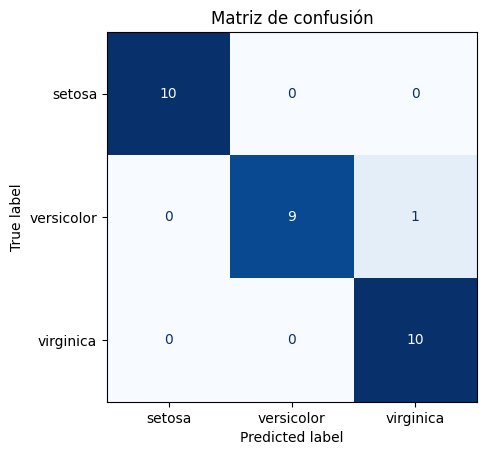

Exactitud: 0.967


In [16]:
cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(colorbar=False, cmap='Blues')
plt.title('Matriz de confusión')
plt.show()
ACC = np.mean(Y_pred == Y_test)
print(f"Exactitud: {ACC:.3f}")